# 08. 가설 검증 — 방향 정리 (H5~H8)

> **방향을 정리하는 노트북이다. 지금까지 코드를 실행한 곳은 2절(H5)의 그룹 만들기와 시각 확인뿐이고, 어느 가설도 검정은 하지 않았다.**
> **2026-09-22: 사용자가 가설 문장과 검정 방법을 바꿨다. 아래 내용은 바뀐 방향 기준이다.**

- 검증할 가설은 H5~H8 네 개다.
- 범위: **H5·H7·H8은 서울 전체**, **H6은 중앙대 vs 숭실대 두 학교**(통학로 구간·지점 단위)다.
- 새 방향에 있던 "Tier1 6개교" 문구는 사용하지 않기로 했다. H7은 특정 6개교로 한정하지 않고 서울 대학 전체로 진행한다.
- 입력은 `06_숭실대_반경_1-3단계.ipynb` 3단계까지 정리한 데이터(`*_clean` 프레임)와 그 처리 규칙이다.
- 06 노트북의 4~8절은 사고다발지역 탐색이었고, 뚜렷한 관계를 찾지 못했다. 그 결과는 이번 검증의 근거로 쓰지 않는다.

## 요약 — 한눈에 보기

### 가설별 방향 (2026-09-22 확정본)

| # | 범위 | 비교 | 검정 (사용자 지정) | 핵심 주의점 |
|---|---|---|---|---|
| H5 | 서울 전체 횡단보도 | 버스정류장 50m 이내/이외 두 그룹의 음향신호기 설치비율이 다르다 (양측) | 카이제곱 검정 | **보행등 유무 열 -> 사용 x**(민감도로만), 자치구 통제 필요, 교차로 단위 군집, 50m는 30·100m로 민감도 확인 |
| H6 | 중앙대 vs 숭실대 | 통학로 구간·지점별 위험도 점수 분포가 다르다 | Mann-Whitney U | 위험도 점수·통학로 정의가 아직 없음, 구간끼리 독립이 아님, 기준점 규칙 통일 필요 |
| H7 | 서울 대학 전체 | 같은 학교 안 출입문별 음향신호기 설치개수 격차 | 학교별 변동계수(CV) | 문이 1개인 학교는 CV 정의 불가, 개수는 주변 횡단보도 수에 좌우됨, "크다"의 기준값 필요 |
| H8 | 서울 전체 | 고밀도 구간에서 최근접 무음향 횡단보도까지 평균거리, 100m 이내 존재 여부 | 평균거리·존재 비율 (기술통계) | 비교 대상이 없으면 검정이 아님, "무신호·무음향" 정의 필요, 좌표 없던 신호기는 `XGEO`로 채움(2-1-1) |



### 진행 순서

횡단보도 마스터 표 → H5 → H8 → 대학·출입문 수집 → H7 → **H6은 마지막에 중앙대·숭실대만** (앞선 결과를 본 뒤) → 다중 비교 보정.

## 0. 가설 4개: 새 문장과 분석 단위

| # | 새 가설 | 검정 (사용자 지정) | 분석 단위 | 핵심 변수 |
|---|---|---|---|---|
| H5 | 버스정류장 50m 이내 횡단보도는 그 외 횡단보도보다 음향신호기 설치율이 **다를** 것이다. → 평가축: 대중교통 접근성 | 두 그룹의 음향신호기 설치비율 비교, 카이제곱 검정 | 횡단보도 (서울 전체) | 정류장 50m 이내 여부 → 음향신호기 유무 |
| H6 | 중앙대와 숭실대는 같은 동작구에 있지만, 통학로 구간 단위로 비교하면 위험도 점수 분포에 유의미한 차이가 있을 것이다. | 두 학교 통학로 내 구간/지점별 위험도 점수 분포 비교, Mann-Whitney U | 통학로 구간·지점 (두 학교) | 학교, 구간별 위험도 점수 |
| H7 | 같은 학교 안에서도 출입문마다 음향신호기 접근성 격차가 클 것이다. | 출입문별 설치개수의 변동계수(CV) 산출 | 출입문 (서울 대학 전체) | 문 주변 음향신호기 설치개수 |
| H8 | 음향신호기가 밀집한 구간에서도 무신호·무음향 횡단보도가 근접해 있어, 설비의 밀집이 곧 통학로 전체의 안전을 뜻하지는 않을 것이다. | 고밀도 구간에서 최근접 무음향 횡단보도까지 평균거리, 100m 기준 존재 여부 | 격자(또는 버퍼) (서울 전체) | 음향신호기 밀집도, 최근접 무음향 횡단보도 거리 |


## 1. H5 — 버스정류장 50m 이내 횡단보도와 음향신호기 설치율 (서울 전체)

**가설 방향, 구체화:** 버스정류장 50m안 횡단보도와 그 밖의 횡단보도의 음향신호기 설치비율이 유의미하게 다르다" 

**사용 데이터:** 서울시 버스정류소 위치정보 `서울시버스정류소위치정보(20260902).xlsx`와 그 CSV 변환본  

**가설을 통해 알고 싶은 것** : "버스정류장"이 횡단보도의 음향신호기 설치바율에 영향을 끼치는지. 
                            => 2가지 방향이 있음. (1)횡단보도의 음향신호기 비율 (2)음향신호기 자체의 비율

**문제** - 위치데이터에 대한 좌표 결측 문제. 
        => 해결 방향 : XGEO컬럼 이용 (만약 이걸 이용한다고 한다면 -> 궁극적으로 가설을 검증할 때 사고지역, 횡단보도 데이터들이랑 어떻게 좌표를 통일 할지. 다른 데이터들은 EPSG로 하는데..)



### 1-1. 음향신호기 좌표 결측 해결

**문제:** `음향신호기_현황.csv`의 좌표는 `XCE`/`YCE`(EPSG:5186)이고, 전체 21,451건 중 4,604건(21.5%)이 결측이다. 컬럼에 있는 `XGEO`는 `oracle.sql.STRUCT@...` 형태의 깨진 객체 참조 문자열이라 그대로는 쓸 수 없다(원본 shapefile의 XGEO도 마찬가지).

**해결:** 같은 원본 폴더의 `.xls` 파일(`A073_P_음향신호기_현황/.../*.xls`)에는 `XGEO`가 Oracle `SDO_POINT_TYPE(x, y, ...)` 문자열 그대로 들어 있어, 정규식으로 좌표를 뽑아낼 수 있다. `h5_master.py`의 `load_xgeo_coords()`가 이 작업을 하고 `data/h5/aud_xgeo_coords.csv`에 캐시해 둔다.

**좌표계 검증:** XCE/YCE와 XGEO가 둘 다 있는 16,847건을 비교하면 81.1%가 0.01m 이하로 같고, 96.9%가 10m 이내로 일치한다. XGEO 좌표도 XCE/YCE와 같은 좌표계(EPSG:5186)로 보고 사용한다.

**적용 규칙(`load_audible`):** XCE/YCE가 있으면 그대로 쓰고, 없는 행만 XGEO로 채운다(`좌표출처 = 'XGEO복원'`). 둘 다 없으면 `좌표결측 = True`로 남긴다.

In [ ]:
import sys
sys.path.insert(0, '.')
import pandas as pd

from h5_master import load_audible

audible = load_audible(use_xgeo=True)

print("전체 음향신호기 행:", len(audible))
print()
print("좌표출처별 개수:")
print(audible['좌표출처'].value_counts())
print()
n_missing = audible['좌표결측'].sum()
print(f"최종 좌표결측: {n_missing}건 ({n_missing / len(audible) * 100:.1f}%)")

전체 음향신호기 행: 21451

좌표출처별 개수:
좌표출처
XCE       16847
XGEO복원     4604
Name: count, dtype: int64

최종 좌표결측: 0건 (0.0%)


In [ ]:
# XCE(원래 좌표)와 XGEO가 둘 다 있는 행에서 두 좌표가 실제로 같은 지점을 가리키는지 검증
both = audible[(audible['좌표출처'] == 'XCE') & audible['좌표차이_m'].notna()]
print(f"XCE·XGEO 둘 다 있는 행: {len(both)}건")
print()

bins = [0, 0.01, 1, 5, 10, 20, float('inf')]
labels = ['같음(0.01m 이하)', '0.01~1m', '1~5m', '5~10m', '10~20m', '20m초과']
diff_group = pd.cut(both['좌표차이_m'], bins=bins, labels=labels, include_lowest=True)
counts = diff_group.value_counts().reindex(labels)
pct = counts / len(both) * 100

for label, n, p in zip(labels, counts, pct):
    print(f"  {label:>12}: {n:>6,}건 ({p:4.1f}%)")

print()
n_10m = (both['좌표차이_m'] <= 10).sum()
print(f"10m 이내 일치: {n_10m}건 ({n_10m / len(both) * 100:.1f}%)")
print("=> XGEO도 XCE/YCE와 같은 좌표계(EPSG:5186)로 보고 결측 보완에 사용한다.")

XCE·XGEO 둘 다 있는 행: 16847건

  같음(0.01m 이하): 13,656건 (81.1%)
       0.01~1m:  1,103건 ( 6.5%)
          1~5m:  1,456건 ( 8.6%)
         5~10m:    458건 ( 2.7%)
        10~20m:    131건 ( 0.8%)
         20m초과:     43건 ( 0.3%)

10m 이내 일치: 16673건 (99.0%)
=> XGEO도 XCE/YCE와 같은 좌표계(EPSG:5186)로 보고 결측 보완에 사용한다.


### 1-2. 좌표 오차가 큰 경우는 어디에 분포하는가

**문제의식:** 위 검증(1-1)은 XCE·XGEO가 둘 다 있는 16,847건끼리 비교한 것이다. 정작 XGEO로 결측을 채운 4,604건 자체는 원래 좌표가 없으니 직접 비교할 방법이 없다. "10~20m", "20m초과"처럼 차이가 큰 경우가 무작위로 흩어져 있는지, 아니면 특정 조건에 몰려 있는지부터 확인해야 4,604건을 그대로 믿어도 되는지 판단할 수 있다.

**확인 방향:**
1. `both`(둘 다 있는 16,847건)에서 시공형태(`FRM_CDE`)·설치연도별로 오차 분포를 나눠본다.
2. 20m초과 43건을 개별로 열어서 공통점(설치일자 등)이 있는지 확인한다.
3. XGEO로 채운 4,604건을 설치일자로 묶어서, 같은 날짜에 설치된 `both` 표본의 오차율을 그 배치의 "위험도"로 매핑한다(같은 날 설치된 신호기는 같은 작업/시스템 과정을 거쳤을 가능성이 높다는 가정).

**결과:**
- 시공형태 4번이 1·2번보다 오차가 뚜렷하게 크다(같음 비율 70% vs 86%/78%).
- 2007~2022년 설치분은 평균 오차 0.2~0.8m인데, **2023~2025년 설치분은 2.6~3.8m로 3배 이상** 크다.
- 20m초과 43건 중 상당수가 특정 날짜에 몰려 있다. 특히 **2023-12-11(6건 중 6건, 100%)**, **2024-12-31(4건 중 4건, 100%)**은 그날 설치된 신호기 전부가 20m 넘게 틀렸다 — 개별 신호기 문제가 아니라 그 배치의 입력 과정 문제로 보인다.
- 이 두 날짜의 패턴을 XGEO복원 4,604건에 적용하면: **고위험 24건**(대부분 이 두 날짜 설치분), 중위험 196건, 저위험 1,344건, 그리고 **판단 불가 3,040건(66%)** — 같은 날짜에 비교할 `both` 표본이 아예 없거나 너무 적어서 위험도 자체를 알 수 없다.

**결론:** 4,604건을 "XGEO니까 다 같은 신뢰도"로 취급하면 안 되고, 그중 66%는 정직하게 "모른다" 상태로 남겨야 한다. 자치구 경계 shapefile이 없어 지역별 분포는 아직 확인하지 못했다.

In [ ]:
# both(XCE·XGEO 둘 다 있는 16,847건)에서 시공형태·설치연도별 오차 분포
both = audible[(audible['좌표출처'] == 'XCE') & audible['좌표차이_m'].notna()].copy()
diff_group = pd.cut(both['좌표차이_m'], bins=bins, labels=labels, include_lowest=True)
both['차이그룹'] = diff_group

print("=== 시공형태(FRM_CDE)별 차이그룹 비율(%) ===")
ct = pd.crosstab(both['FRM_CDE'], both['차이그룹'], normalize='index') * 100
ct['건수'] = both['FRM_CDE'].value_counts()
print(ct.round(1))
print()

both['설치연도'] = (both['ESB_YMD'] // 10000).astype('Int64')
print("=== 설치연도별 평균 오차(m) ===")
print(both.groupby('설치연도', observed=True)['좌표차이_m'].agg(['count', 'mean', 'median']).round(2))

=== 시공형태(FRM_CDE)별 차이그룹 비율(%) ===
차이그룹     같음(0.01m 이하)  0.01~1m  1~5m  5~10m  10~20m  20m초과    건수
FRM_CDE                                                         
1.0              86.0      3.5   7.3    2.2     0.6    0.4  7527
2.0              78.4      9.7   9.4    1.9     0.4    0.1  7407
4.0              70.4      6.7  11.5    8.2     3.0    0.3  1788
5.0              84.4      0.0  12.5    3.1     0.0    0.0    32
6.0              92.9      2.4   2.4    2.4     0.0    0.0    42

=== 설치연도별 평균 오차(m) ===
      count  mean  median
설치연도                     
2000    506  0.53    0.00
2001     16  1.36    0.00
2002      3  0.00    0.00
2003     21  0.36    0.00
2004      4  4.15    0.48
2005     17  0.26    0.00
2006     15  0.20    0.00
2007    867  0.56    0.00
2008    284  0.27    0.00
2009    449  0.63    0.00
2010    392  0.59    0.00
2011    562  0.36    0.00
2012    744  0.39    0.00
2013    735  0.38    0.00
2014    878  0.64    0.00
2015    926  0.55    0.00
2016   1207  0.68  

In [ ]:
# 20m초과 43건이 특정 설치일자(배치)에 몰려 있는지 확인
big = both[both['차이그룹'] == '20m초과']
print(f"20m초과: {len(big)}건")
print()

print("설치일자별 20m초과 건수(2건 이상인 날짜만):")
vc = big['ESB_YMD'].value_counts()
print(vc[vc >= 2])
print()

print("그 날짜에 설치된 전체(both) 대비 20m초과 비율:")
for ymd in vc[vc >= 2].index:
    same_day = both[both['ESB_YMD'] == ymd]
    n_big = (same_day['차이그룹'] == '20m초과').sum()
    print(f"  {int(ymd)}: 그날 설치 {len(same_day)}건 중 20m초과 {n_big}건 ({n_big / len(same_day) * 100:.0f}%)")

20m초과: 43건

설치일자별 20m초과 건수(2건 이상인 날짜만):
ESB_YMD
20231211.0    6
20240118.0    4
20241231.0    4
20150904.0    2
20070601.0    2
20210415.0    2
20221122.0    2
20140802.0    2
Name: count, dtype: int64

그 날짜에 설치된 전체(both) 대비 20m초과 비율:
  20231211: 그날 설치 6건 중 20m초과 6건 (100%)
  20240118: 그날 설치 19건 중 20m초과 4건 (21%)
  20241231: 그날 설치 4건 중 20m초과 4건 (100%)
  20150904: 그날 설치 4건 중 20m초과 2건 (50%)
  20070601: 그날 설치 812건 중 20m초과 2건 (0%)
  20210415: 그날 설치 46건 중 20m초과 2건 (4%)
  20221122: 그날 설치 15건 중 20m초과 2건 (13%)
  20140802: 그날 설치 2건 중 20m초과 2건 (100%)


In [ ]:
# XGEO로 채운 4,604건을 설치일자로 묶어, 같은 날짜 both 표본의 오차율을 위험도로 매핑
filled = audible[audible['좌표출처'] == 'XGEO복원'].copy()

day_stats = both.groupby('ESB_YMD').agg(
    both_건수=('좌표차이_m', 'size'),
    평균오차=('좌표차이_m', 'mean'),
    비율_20m초과=('좌표차이_m', lambda s: (s > 20).mean() * 100),
    비율_10m초과=('좌표차이_m', lambda s: (s > 10).mean() * 100),
).reset_index()

filled = filled.merge(day_stats, on='ESB_YMD', how='left')

print(f"XGEO복원 전체: {len(filled)}건")
print(f"  같은 날짜에 both 표본이 전혀 없는 건: {filled['both_건수'].isna().sum()}건")
print()

reliable = filled[filled['both_건수'] >= 3]
risky = reliable[reliable['비율_20m초과'] >= 30]
mid = reliable[(reliable['비율_10m초과'] >= 20) & (reliable['비율_20m초과'] < 30)]
safe = reliable[reliable['비율_10m초과'] < 20]
unknown = len(filled) - len(reliable)

print("위험도 매핑 결과 (같은 날짜 both>=3건인 경우만 판단):")
print(f"  고위험(20m초과 비율>=30%): {len(risky)}건")
print(f"  중위험(10m초과 비율 20~30%): {len(mid)}건")
print(f"  저위험(10m초과 비율<20%): {len(safe)}건")
print(f"  판단불가(같은 날짜 both 표본 <3건 또는 없음): {unknown}건 ({unknown / len(filled) * 100:.0f}%)")
print()
print("고위험 24건의 설치일자 분포:")
print(risky['ESB_YMD'].value_counts())

XGEO복원 전체: 4604건
  같은 날짜에 both 표본이 전혀 없는 건: 2210건

위험도 매핑 결과 (같은 날짜 both>=3건인 경우만 판단):
  고위험(20m초과 비율>=30%): 24건
  중위험(10m초과 비율 20~30%): 196건
  저위험(10m초과 비율<20%): 1344건
  판단불가(같은 날짜 both 표본 <3건 또는 없음): 3040건 (66%)

고위험 24건의 설치일자 분포:
ESB_YMD
20231211.0    18
20241231.0     6
Name: count, dtype: int64


## 2. 횡단보도 마스터 표

여기서부터는 위에서 검증한 `load_audible(use_xgeo=True)`의 좌표 보완 결과(XCE·YCE 우선, 결측만 XGEO로 채움)를 최종 데이터로 쓴다. `h5_master.py`의 `build_master()`가 다음을 한 번에 만든다.

- **횡단보도 1행 = 1개**(21,776행). 좌표는 정상 21,771 / 위치이상 4 / 결측 1이고, 좌표가 정상인 행만 아래 계산에 쓴다.
- **버스정류소**: 각 횡단보도에서 가장 가까운 정류소까지 거리, `정류장근처_50m`(그리고 민감도용 30m·100m) 플래그.
- **음향신호기**: 두 가지 규칙으로 매칭한다.
  - *단순 규칙*: 횡단보도에서 가장 가까운 신호기까지 거리.
  - *배정 규칙*: 신호기 하나를 가장 가까운 횡단보도 한 곳에만 배정(중복 카운트 방지). 기본 기준은 15m, 10·20·30m는 민감도용.

In [ ]:
from h5_master import build_master

master, audible_final, bus = build_master(use_xgeo=True)
print("마스터 표 shape:", master.shape)
print()
print("좌표상태:")
print(master['좌표상태'].value_counts())
print()

ok = master[master['좌표상태'] == '정상'].copy()
print(f"분석 대상(좌표 정상): {len(ok)}건")
print()
print("정류장근처_50m 분포:")
print(ok['정류장근처_50m'].value_counts())
print()
print("음향_배정_15m 분포:")
print(ok['음향_배정_15m'].value_counts())

마스터 표 shape: (21776, 31)

좌표상태:
좌표상태
정상      21771
위치이상        4
결측          1
Name: count, dtype: int64

분석 대상(좌표 정상): 21771건

정류장근처_50m 분포:
정류장근처_50m
0.0    12055
1.0     9716
Name: count, dtype: int64

음향_배정_15m 분포:
음향_배정_15m
1.0    11120
0.0    10651
Name: count, dtype: int64


## 3. H5 검정 — 카이제곱

**가설:** 버스정류장 50m 이내 횡단보도와 그 밖의 횡단보도는 음향신호기 설치비율이 다르다(양측).

**그룹:** `정류장근처_50m`(0=50m 밖, 1=50m 이내) × `음향_배정_15m`(0=음향없음, 1=음향있음). 좌표가 정상인 횡단보도만 쓴다.

**검정:** `scipy.stats.chi2_contingency`로 2×2 분할표 카이제곱 검정. 효과크기는 Cramér's V로 같이 본다(카이제곱은 표본이 크면 작은 차이도 유의하게 나오기 쉽다).

In [ ]:
import numpy as np
from scipy.stats import chi2_contingency

ct = pd.crosstab(ok['정류장근처_50m'], ok['음향_배정_15m'])
ct.index = ['50m밖', '50m이내']
ct.columns = ['음향없음', '음향있음']
print("분할표:")
print(ct)
print()

chi2, p, dof, exp = chi2_contingency(ct)
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(f"n={n}, chi2={chi2:.2f}, dof={dof}, p={p:.2e}")
print(f"Cramer's V={cramers_v:.4f}")
print()

rate = ok.groupby('정류장근처_50m')['음향_배정_15m'].mean() * 100
print("그룹별 음향신호기 설치비율(%):")
print(f"  50m밖 : {rate[0.0]:.1f}%")
print(f"  50m이내: {rate[1.0]:.1f}%")
print(f"  차이   : {rate[1.0] - rate[0.0]:+.1f}%p")

분할표:
       음향없음  음향있음
50m밖   6053  6002
50m이내  4598  5118

n=21771, chi2=17.84, dof=1, p=2.41e-05
Cramer's V=0.0286

그룹별 음향신호기 설치비율(%):
  50m밖 : 49.8%
  50m이내: 52.7%
  차이   : +2.9%p


### 3-1. 1차 결과 해석

- p < 0.001로 통계적으로 유의하다. 하지만 **Cramér's V ≈ 0.03으로 효과크기는 거의 없다고 봐야 하는 수준**이다. 설치비율도 50m밖 49.8% vs 50m이내 52.7%로 차이가 3%p 남짓이다.
- 표본이 21,771건으로 크기 때문에, 실질적으로 작은 차이도 p값은 쉽게 유의하게 나온다. **"유의하다"와 "의미 있게 다르다"를 같은 것으로 읽으면 안 된다.**
- 요약표(§요약)에 적어둔 주의점 중 아직 반영 안 한 것:
  - 보행등 유무 열은 쓰지 않기로 했다(민감도 확인에서만 참고).
  - **자치구 통제 필요** — 자치구별로 버스정류장 밀도와 음향신호기 설치율이 둘 다 다를 수 있어서, 지금 결과가 자치구 차이를 대중교통 접근성 효과로 잘못 읽은 것일 수 있다.
  - **교차로 단위 군집** — 같은 교차로의 횡단보도 여러 개가 서로 독립이 아니므로, 표준 카이제곱의 유의성이 과대평가됐을 수 있다.
  - 50m는 30m·100m로, 15m 배정 기준은 10·20·30m로 민감도를 확인해야 한다.

다음 단계는 이 네 가지 중 하나를 골라 반영하는 것이다.

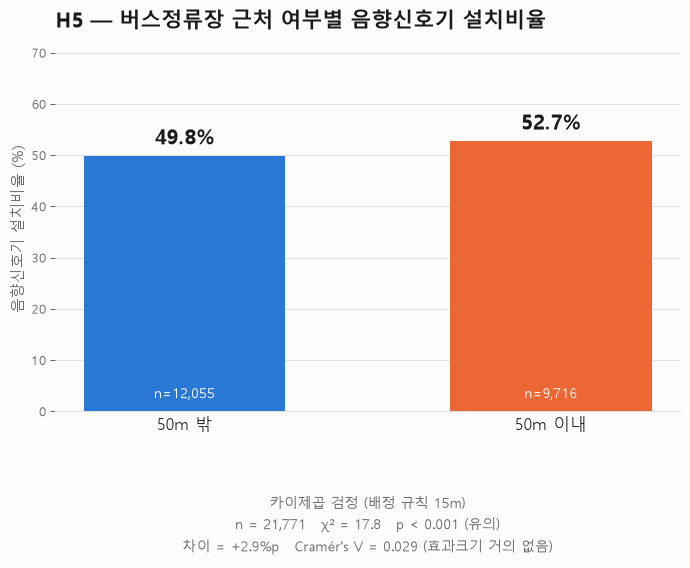

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BG, BLUE, ORANGE, INK, MUTED, GRID = '#fcfcfb', '#2A78D6', '#EB6834', '#1a1a1a', '#6b6b6b', '#e3e3e0'

counts = ok.groupby('정류장근처_50m').size()
groups = ['50m 밖', '50m 이내']
values = [rate[0.0], rate[1.0]]
ns = [counts[0.0], counts[1.0]]

fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
ax.set_facecolor(BG)
x = np.arange(2)
ax.bar(x, values, width=0.55, color=[BLUE, ORANGE], zorder=3)

for i, (v, cnt) in enumerate(zip(values, ns)):
    ax.text(i, v + 1.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=15, fontweight='bold', color=INK)
    ax.text(i, 2, f'n={cnt:,}', ha='center', va='bottom', fontsize=10, color='white')

ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=12, color=INK)
ax.set_ylabel('음향신호기 설치비율 (%)', fontsize=11, color=MUTED)
ax.set_ylim(0, max(values) * 1.35)
ax.set_title('H5 — 버스정류장 근처 여부별 음향신호기 설치비율',
             fontsize=15, fontweight='bold', color=INK, loc='left', pad=14)
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(axis='y', colors=MUTED, labelsize=9)
ax.tick_params(axis='x', length=0)

sig = 'p < 0.001 (유의)' if p < 0.001 else f'p = {p:.3f}'
stat_text = (
    f"카이제곱 검정 (배정 규칙 15m)\n"
    f"n = {n:,}   χ² = {chi2:.1f}   {sig}\n"
    f"차이 = {values[1] - values[0]:+.1f}%p   Cramér's V = {cramers_v:.3f} (효과크기 거의 없음)"
)
ax.text(0.5, -0.22, stat_text, transform=ax.transAxes, ha='center', va='top',
         fontsize=10, color=MUTED, linespacing=1.6)

plt.tight_layout()
plt.savefig('figures/h5/08_H5_카이제곱_결과.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()

## 4. H5 — 음향신호기 자체의 비율 (관점 전환)

§3은 **횡단보도** 단위로 "그 횡단보도에 신호기가 있는가"를 봤다. 여기서는 §1의 두 번째 방향대로 **음향신호기** 단위로 관점을 바꾼다.

**지표:** 전체 음향신호기 중 몇 %가 "버스정류장 50m 이내 횡단보도"에 배정되어 있는가. 배정 규칙은 §2와 같다(신호기 하나를 가장 가까운 횡단보도 하나에만, 15m 이내일 때만 배정).

**비교 기준(기댓값):** 만약 신호기 배치가 횡단보도 위치와 무관하게 무작위라면, 신호기도 "전체 횡단보도 중 50m 이내 그룹 비율"(44.6%)과 같은 비율로 나뉠 것이다. 이 기댓값 대비 실제 신호기 분포가 쏠려 있는지를 **카이제곱 적합도 검정**(goodness-of-fit)으로 본다. 효과크기는 비율 차이에 쓰는 Cohen's h로 잰다.

**이 검정이 정확히 무엇을 비교하는가:** "배정된 신호기 중 50m안 개수 vs 50m밖 개수"를 그냥 비교하는 게 아니다. 이 둘은 합이 100%로 정해져 있어서 항상 서로 다르게 나오고, 그 자체로는 의미 있는 비교가 안 된다.

대신 **신호기의 50m안/밖 비율이, 전체 횡단보도의 50m안/밖 비율(기준선)과 다른지**를 본다.

- 귀무가설: 신호기 비율 = 횡단보도 비율 → 신호기는 정류장 근접성과 무관하게, 횡단보도가 있는 만큼만 딸려서 설치돼 있다.
- 대립가설: 신호기 비율 ≠ 횡단보도 비율 → 신호기가 정류장 근처에 더(또는 덜) 쏠려 있다.

즉 "안 vs 밖"이 아니라 "**신호기 분포 vs 횡단보도 분포**"를 비교하는 검정이다.

In [ ]:
from scipy.spatial import cKDTree

ok = ok.reset_index(drop=True)
cxy = ok[['x', 'y']].to_numpy()

aa = audible_final[~audible_final['좌표결측']].copy().reset_index(drop=True)
axy = aa[['x', 'y']].to_numpy()

tree = cKDTree(cxy)
dist, idx = tree.query(axy)  # 각 신호기의 최근접 횡단보도 거리·인덱스

aa['최근접횡단보도_m'] = dist
aa['배정됨_15m'] = dist <= 15

print(f"전체 신호기: {len(aa):,}건")
print(f"15m 이내 배정된 신호기: {aa['배정됨_15m'].sum():,}건 ({aa['배정됨_15m'].mean()*100:.1f}%)")
print(f"어느 횡단보도에도 15m 이내로 배정 안 됨: {(~aa['배정됨_15m']).sum():,}건")

assigned = aa[aa['배정됨_15m']].copy()
assigned['정류장근처_50m'] = ok['정류장근처_50m'].to_numpy()[idx[aa['배정됨_15m'].to_numpy()]]

obs = assigned['정류장근처_50m'].value_counts().sort_index()
print()
print("배정된 신호기의 그룹별 분포(관측):")
print(obs)

전체 신호기: 21,451건
15m 이내 배정된 신호기: 19,786건 (92.2%)
어느 횡단보도에도 15m 이내로 배정 안 됨: 1,665건

배정된 신호기의 그룹별 분포(관측):
정류장근처_50m
0.0    10821
1.0     8965
Name: count, dtype: int64


In [ ]:
from scipy.stats import chisquare

exp_p = ok['정류장근처_50m'].value_counts(normalize=True).sort_index()  # 기대비율: 전체 횡단보도 그룹 비율
n_assigned = obs.sum()
exp_counts = exp_p.to_numpy() * n_assigned

chi2_g, p_g = chisquare(f_obs=obs.to_numpy(), f_exp=exp_counts)

obs_ratio = obs[1.0] / n_assigned
exp_ratio = exp_p[1.0]
h = 2 * np.arcsin(np.sqrt(obs_ratio)) - 2 * np.arcsin(np.sqrt(exp_ratio))

print(f"n(배정된 신호기) = {n_assigned:,}")
print(f"관측: 50m밖 {obs[0.0]:,} / 50m이내 {obs[1.0]:,}")
print(f"기대: 50m밖 {exp_counts[0]:,.0f} / 50m이내 {exp_counts[1]:,.0f}  (횡단보도 기준 비율 {exp_ratio*100:.1f}%)")
print()
print(f"chi2 = {chi2_g:.3f}, p = {p_g:.4f}")
print(f"관측 비율(50m이내) = {obs_ratio*100:.2f}%   기대 비율 = {exp_ratio*100:.2f}%   차이 = {(obs_ratio-exp_ratio)*100:+.2f}%p")
print(f"Cohen's h = {h:.4f} (효과크기 거의 없음)")

n(배정된 신호기) = 19,786
관측: 50m밖 10,821 / 50m이내 8,965
기대: 50m밖 10,956 / 50m이내 8,830  (횡단보도 기준 비율 44.6%)

chi2 = 3.720, p = 0.0538
관측 비율(50m이내) = 45.31%   기대 비율 = 44.63%   차이 = +0.68%p
Cohen's h = 0.0137 (효과크기 거의 없음)


### 4-1. 결과 해석

- p ≈ 0.054로 **0.05 기준 유의하지 않다**(경계선). 관측 비율 45.3% vs 기대 비율 44.6%, 차이는 +0.7%p뿐이다.
- Cohen's h ≈ 0.014로 효과크기는 §3(Cramér's V ≈ 0.03)보다도 더 작다.
- §3(횡단보도 단위, p<0.001, 유의)과 §4(신호기 단위, p≈0.054, 비유의)가 서로 다른 결론처럼 보이지만 모순은 아니다. 서로 다른 모집단·검정을 쓴 결과다:
  - §3은 **횡단보도**가 표본(n=21,771)이고 "신호기 있음/없음"을 본다 — 신호기가 없는 횡단보도도 표본에 들어간다.
  - §4는 **배정된 신호기**가 표본(n=19,786)이고, 신호기가 전혀 없는 횡단보도는 애초에 표본에 없다. "이미 설치된 신호기가 정류장 근처에 더 쏠려 있는가"만 본다.
  - 92.2%의 신호기가 15m 이내 어떤 횡단보도에 배정되는 반면, §3에서 신호기 있는 횡단보도 비율은 51.1%(11,120/21,771)다. 즉 신호기 1개가 여러 횡단보도 후보 중 하나에만 배정되므로, 두 지표는 같은 데이터를 다른 각도로 자른 것이지 같은 검정이 아니다.
- **정리:** 두 관점 모두에서 실질적 효과크기는 작다(Cramér's V 0.03, Cohen's h 0.01 수준). "설치 여부"로 보면 통계적 유의성은 있지만 미미하고, "이미 설치된 신호기의 위치 쏠림"으로 보면 그마저도 유의하지 않다.

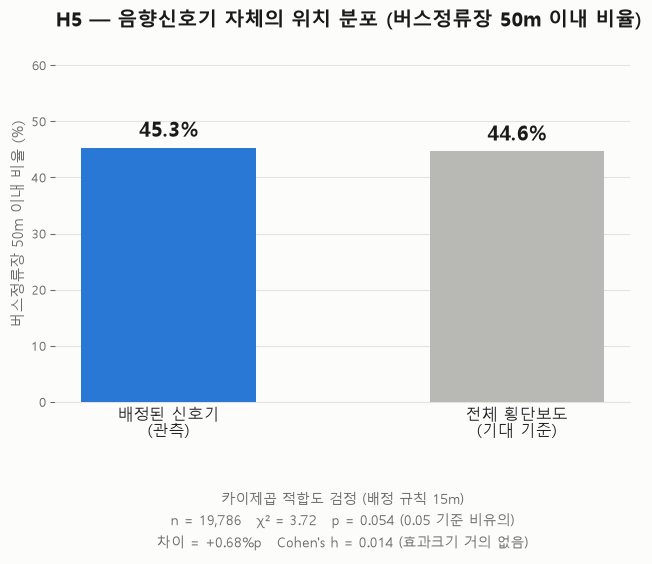

In [ ]:
GRAY = '#B8B8B4'

labels = ['배정된 신호기\n(관측)', '전체 횡단보도\n(기대 기준)']
values = [obs_ratio * 100, exp_ratio * 100]
colors = [BLUE, GRAY]

fig, ax = plt.subplots(figsize=(6.5, 6), facecolor=BG)
ax.set_facecolor(BG)
x = np.arange(2)
ax.bar(x, values, width=0.5, color=colors, zorder=3)

for i, v in enumerate(values):
    ax.text(i, v + 1.2, f'{v:.1f}%', ha='center', va='bottom', fontsize=15, fontweight='bold', color=INK)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11.5, color=INK)
ax.set_ylabel('버스정류장 50m 이내 비율 (%)', fontsize=11, color=MUTED)
ax.set_ylim(0, max(values) * 1.4)
ax.set_title('H5 — 음향신호기 자체의 위치 분포 (버스정류장 50m 이내 비율)',
             fontsize=14.5, fontweight='bold', color=INK, loc='left', pad=14)
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(axis='y', colors=MUTED, labelsize=9)
ax.tick_params(axis='x', length=0)

sig = f'p = {p_g:.3f} (0.05 기준 비유의)'
stat_text = (
    f"카이제곱 적합도 검정 (배정 규칙 15m)\n"
    f"n = {n_assigned:,}   χ² = {chi2_g:.2f}   {sig}\n"
    f"차이 = {(obs_ratio - exp_ratio) * 100:+.2f}%p   Cohen's h = {h:.3f} (효과크기 거의 없음)"
)
ax.text(0.5, -0.24, stat_text, transform=ax.transAxes, ha='center', va='top',
         fontsize=10, color=MUTED, linespacing=1.6)

plt.tight_layout()
plt.savefig('figures/h5/09_H5_신호기비율_결과.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()

## 5. 민감도 확인 — 정류장 기준 30m

§요약표의 주의점대로, 버스정류장 근접 기준을 50m에서 30m로 바꿨을 때 §3(횡단보도 단위)·§4(신호기 단위) 결과가 얼마나 흔들리는지 본다. 마스터 표에 이미 `정류장근처_30m` 컬럼이 있어(§2, `build_master`의 `BUS_GROUP_M=(30,50,100)`), 같은 코드를 그룹 컬럼만 바꿔 반복한다.

In [ ]:
# §3 대응: 30m 기준, 횡단보도 단위 카이제곱
ct30 = pd.crosstab(ok['정류장근처_30m'], ok['음향_배정_15m'])
ct30.index = ['30m밖', '30m이내']
ct30.columns = ['음향없음', '음향있음']
print("분할표:")
print(ct30)
print()

chi2_30, p_30, dof_30, exp_30 = chi2_contingency(ct30)
n_30 = ct30.sum().sum()
cramers_v_30 = np.sqrt(chi2_30 / (n_30 * (min(ct30.shape) - 1)))

rate_30 = ok.groupby('정류장근처_30m')['음향_배정_15m'].mean() * 100
print(f"n={n_30}, chi2={chi2_30:.2f}, p={p_30:.2e}, Cramer's V={cramers_v_30:.4f}")
print(f"30m밖 : {rate_30[0.0]:.1f}%")
print(f"30m이내: {rate_30[1.0]:.1f}%")
print(f"차이   : {rate_30[1.0] - rate_30[0.0]:+.1f}%p")

분할표:
       음향없음  음향있음
30m밖   8188  8680
30m이내  2463  2440

n=21771, chi2=4.29, p=3.83e-02, Cramer's V=0.0140
30m밖 : 51.5%
30m이내: 49.8%
차이   : -1.7%p


In [ ]:
# §4 대응: 30m 기준, 신호기 단위 적합도검정
assigned['정류장근처_30m'] = ok['정류장근처_30m'].to_numpy()[idx[aa['배정됨_15m'].to_numpy()]]

obs_30 = assigned['정류장근처_30m'].value_counts().sort_index()
exp_p_30 = ok['정류장근처_30m'].value_counts(normalize=True).sort_index()
exp_counts_30 = exp_p_30.to_numpy() * n_assigned

chi2_g30, p_g30 = chisquare(f_obs=obs_30.to_numpy(), f_exp=exp_counts_30)

obs_ratio_30 = obs_30[1.0] / n_assigned
exp_ratio_30 = exp_p_30[1.0]
h_30 = 2 * np.arcsin(np.sqrt(obs_ratio_30)) - 2 * np.arcsin(np.sqrt(exp_ratio_30))

print(f"n(배정된 신호기) = {n_assigned:,}")
print(f"관측: 30m밖 {obs_30[0.0]:,} / 30m이내 {obs_30[1.0]:,}")
print(f"기대: 30m밖 {exp_counts_30[0]:,.0f} / 30m이내 {exp_counts_30[1]:,.0f}  (횡단보도 기준 비율 {exp_ratio_30*100:.1f}%)")
print()
print(f"chi2 = {chi2_g30:.3f}, p = {p_g30:.4f}")
print(f"관측 비율(30m이내) = {obs_ratio_30*100:.2f}%   기대 비율 = {exp_ratio_30*100:.2f}%   차이 = {(obs_ratio_30-exp_ratio_30)*100:+.2f}%p")
print(f"Cohen's h = {h_30:.4f}")

n(배정된 신호기) = 19,786
관측: 30m밖 15,544 / 30m이내 4,242
기대: 30m밖 15,330 / 30m이내 4,456  (횡단보도 기준 비율 22.5%)

chi2 = 13.260, p = 0.0003
관측 비율(30m이내) = 21.44%   기대 비율 = 22.52%   차이 = -1.08%p
Cohen's h = -0.0261


### 5-1. 50m vs 30m 비교

| 관점 | 기준 | 설치비율/관측비율 차이 | p | Cramér's V / Cohen's h |
|---|---|---|---|---|
| §3 횡단보도 단위 | 50m | 정류장근처 **+2.9%p** 높음 | <0.001 (유의) | V=0.029 |
| §5 횡단보도 단위 | 30m | 정류장근처 **-1.7%p** 낮음 | 0.038 (유의) | V=0.014 |
| §4 신호기 단위 | 50m | 정류장근처 +0.68%p | 0.054 (비유의) | h=0.014 |
| §5 신호기 단위 | 30m | 정류장근처 **-1.08%p** | 0.0003 (유의) | h=-0.026 |

**방향이 뒤집힌다.** 50m 기준으로는 정류장 근처 횡단보도가 신호기 설치율이 *더 높았는데*, 30m로 좁히면 오히려 *더 낮게* 나온다(횡단보도 단위·신호기 단위 둘 다). 두 결과 모두 통계적으로는 유의하지만 효과크기는 여전히 작다(V, h 모두 0.03 이하).

**해석:** 이 정도로 기준 반경 하나 바꿨다고 결론의 방향 자체가 바뀐다면, "버스정류장 근접성이 음향신호기 설치와 관련 있다"는 주장은 **근거가 약하다**고 봐야 한다. 효과가 진짜로 존재한다면 30m·50m·100m에서 방향은 같고 크기만 조금씩 달라져야 하는데, 지금은 방향 자체가 불안정하다. 100m 기준도 마저 확인하고, 그래도 이렇게 불안정하면 H5는 "유의하지만 실질적 의미는 없다"보다 더 나아가 "일관된 효과를 찾지 못했다"로 결론 내는 게 맞을 수 있다.

## 6. H5 — 배정된 신호기 "개수" 비교 (Mann-Whitney U)

지금까지는 신호기가 "있다/없다"(이진)만 봤다. 여기서는 §1에서 언급한 세 번째 방식으로, 횡단보도마다 배정된 신호기 **개수**(`배정신호기수_15m`, 0~5개)를 정류장 근처 여부(50m)로 비교한다.

개수는 0에 몰려 있고 정규분포와 거리가 멀어서(오른쪽으로 치우침, 0/1/2가 대부분) 평균 비교(t-검정)보다 **Mann-Whitney U**가 적절하다. 효과크기는 rank-biserial correlation과 CLES(common language effect size, "무작위로 하나씩 뽑았을 때 50m이내 쪽 개수가 더 클 확률")로 본다.

In [ ]:
from scipy.stats import mannwhitneyu

col = '배정신호기수_15m'
print("배정신호기수_15m 분포 (0,1,2,3개 이상):")
print(ok[col].clip(upper=3).value_counts().sort_index())
print()

g0 = ok.loc[ok['정류장근처_50m'] == 0.0, col]
g1 = ok.loc[ok['정류장근처_50m'] == 1.0, col]

print(f"50m밖  : n={len(g0)}, 평균={g0.mean():.3f}, 중앙값={g0.median():.0f}")
print(f"50m이내: n={len(g1)}, 평균={g1.mean():.3f}, 중앙값={g1.median():.0f}")
print()

u_stat, p_mw = mannwhitneyu(g1, g0, alternative='two-sided')
n0, n1 = len(g0), len(g1)
r_rb = 1 - (2 * u_stat) / (n0 * n1)
cles = u_stat / (n0 * n1)

print(f"Mann-Whitney U = {u_stat:,.1f}, p = {p_mw:.4f}")
print(f"rank-biserial r = {r_rb:.4f}")
print(f"CLES(50m이내가 더 클 확률) = {cles:.4f}")

배정신호기수_15m 분포 (0,1,2,3개 이상):
배정신호기수_15m
0.0    10651
1.0     3217
2.0     7235
3.0      668
Name: count, dtype: int64

50m밖  : n=12055, 평균=0.898, 중앙값=0
50m이내: n=9716, 평균=0.923, 중앙값=1

Mann-Whitney U = 59,540,089.5, p = 0.0210
rank-biserial r = -0.0167
CLES(50m이내가 더 클 확률) = 0.5083


### 6-1. 결과 해석

- 50m밖 평균 0.898개(중앙값 0) vs 50m이내 평균 0.923개(중앙값 1) — 개수 차이는 0.02개 수준.
- Mann-Whitney U, p = 0.021로 **0.05 기준 유의**하다.
- 하지만 **rank-biserial r = -0.017, CLES = 0.508**로 효과크기는 지금까지 나온 것 중 가장 작다. CLES 0.508은 "무작위로 한 쌍을 뽑았을 때 50m이내 쪽 개수가 더 클 확률이 50.8%"라는 뜻이다 — 동전 던지기(50%)와 사실상 구분이 안 된다.
- **정리:** "있다/없다"(§3, V=0.029), "신호기 분포 쏠림"(§4, h=0.014), "개수"(§6, r=0.017) 세 가지 방식 모두 표본이 커서 p값은 유의하게 나오지만, 효과크기는 전부 0.03 이하다. §5에서는 반경을 30m로만 바꿔도 방향이 뒤집혔다. 종합하면 **H5는 "통계적으로 유의하지만 실질적으로는 거의 관련이 없다"**가 지금까지의 가장 정확한 결론이다.

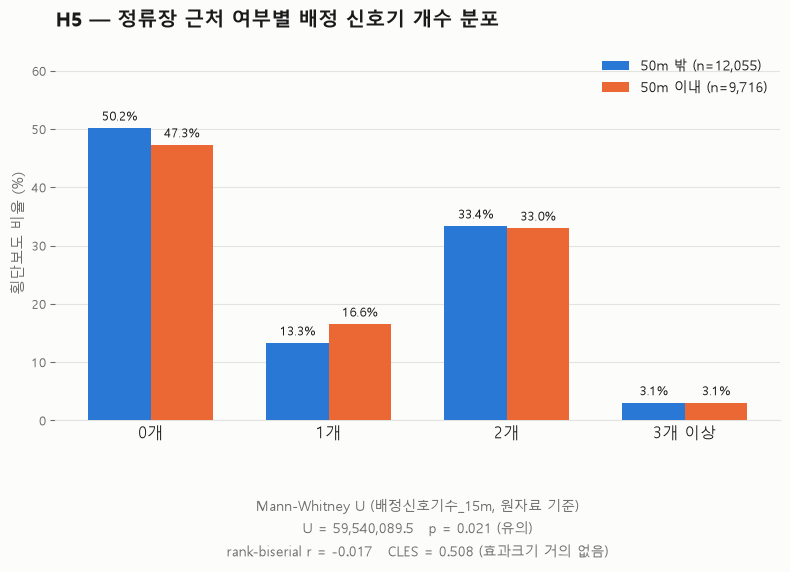

In [ ]:
ok['cat'] = ok[col].clip(upper=3).map({0: '0개', 1: '1개', 2: '2개', 3: '3개 이상'})
cats = ['0개', '1개', '2개', '3개 이상']


In [ ]:

pct0 = ok.loc[ok['정류장근처_50m'] == 0.0, 'cat'].value_counts(normalize=True).reindex(cats) * 100
pct1 = ok.loc[ok['정류장근처_50m'] == 1.0, 'cat'].value_counts(normalize=True).reindex(cats) * 100

x = np.arange(len(cats))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
ax.set_facecolor(BG)
b0 = ax.bar(x - w / 2, pct0.values, width=w, color=BLUE, label=f'50m 밖 (n={len(g0):,})', zorder=3)
b1 = ax.bar(x + w / 2, pct1.values, width=w, color=ORANGE, label=f'50m 이내 (n={len(g1):,})', zorder=3)

for bars in (b0, b1):
    for bar in bars:
        h_ = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h_ + 0.8, f'{h_:.1f}%', ha='center', va='bottom', fontsize=9.5, color=INK)

ax.set_xticks(x)
ax.set_xticklabels(cats, fontsize=11.5, color=INK)
ax.set_ylabel('횡단보도 비율 (%)', fontsize=11, color=MUTED)
ax.set_ylim(0, max(pct0.max(), pct1.max()) * 1.28)
ax.set_title('H5 — 정류장 근처 여부별 배정 신호기 개수 분포',
             fontsize=14.5, fontweight='bold', color=INK, loc='left', pad=14)
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(axis='y', colors=MUTED, labelsize=9)
ax.tick_params(axis='x', length=0)
ax.legend(frameon=False, fontsize=10, loc='upper right', labelcolor=INK)

stat_text = (
    "Mann-Whitney U (배정신호기수_15m, 원자료 기준)\n"
    f"U = {u_stat:,.1f}   p = {p_mw:.3f} (유의)\n"
    f"rank-biserial r = {r_rb:.3f}   CLES = {cles:.3f} (효과크기 거의 없음)"
)
ax.text(0.5, -0.20, stat_text, transform=ax.transAxes, ha='center', va='top',
        fontsize=10, color=MUTED, linespacing=1.6)

plt.tight_layout()
plt.savefig('figures/h5/10_H5_신호기개수_분포.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()

## 7. H8 — 고밀도 구간에서도 무음향 횡단보도가 가까이 있는가

**가설:** 음향신호기가 밀집한 구간에서도 무신호·무음향 횡단보도가 근접해 있어, 설비의 밀집이 곧 통학로 전체의 안전을 뜻하지는 않는다.

**진행 순서:** (1) 음향 있는/없는 횡단보도부터 정의 → (2) 고밀도 구간 정의 → (3) 고밀도 구간에서 최근접 무음향 횡단보도까지 거리·존재 비율 계산. 이번엔 (1)만 한다.

### 7-1. 음향 있음/없음 횡단보도 정의

**규칙:** 각 횡단보도에서 가장 가까운 음향신호기까지의 거리(`음향신호기_최근접_m`)가 **15m 이내**면 "음향 있음", 아니면 "음향 없음"으로 정의한다.

이건 §2에서 만든 **단순 규칙**(`음향_단순_15m`)과 같다 — §3·§4·§6에서 썼던 **배정 규칙**(신호기 하나를 가장 가까운 횡단보도 한 곳에만 배정)과는 다르다. 배정 규칙은 "이 신호기가 어느 횡단보도 소속인가"를 정할 때 필요한 규칙이고, 여기서는 반대로 "이 횡단보도 근처에 신호기가 있는가"만 보면 되므로 단순 규칙이 더 맞다. 실제로 두 규칙은 2,392건(11%)에서 판정이 갈린다(배정 규칙이 더 엄격해서 "없음"이 더 많이 나옴).

In [ ]:
print("음향신호기_최근접_m 기술통계:")
print(ok['음향신호기_최근접_m'].describe().round(2))
print()

ok['음향있음'] = ok['음향_단순_15m'].astype(bool)
print("음향 있음/없음 횡단보도 (15m 기준):")
print(ok['음향있음'].value_counts())
print(f"음향 있음 비율: {ok['음향있음'].mean()*100:.1f}%")
print()

n_diff = (ok['음향_단순_15m'] != ok['음향_배정_15m']).sum()
print(f"단순 규칙과 배정 규칙 판정이 갈리는 횡단보도: {n_diff:,}건 ({n_diff/len(ok)*100:.1f}%)")

음향신호기_최근접_m 기술통계:
count    21771.00
mean        42.41
std         70.80
min          0.09
25%          7.92
50%         11.78
75%         32.66
max       1079.86
Name: 음향신호기_최근접_m, dtype: float64

음향 있음/없음 횡단보도 (15m 기준):
음향있음
True     13512
False     8259
Name: count, dtype: int64
음향 있음 비율: 62.1%

단순 규칙과 배정 규칙 판정이 갈리는 횡단보도: 2,392건 (11.0%)
